## 1. Import libraries & packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## 2. Load the dataset into a dataframe

In [2]:
df=pd.read_csv('data/raw/train.csv')
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. BiVariate Analysis

#### 3.1 Plot the relation between Tyre Compound & PitNextLap

<Axes: xlabel='Compound', ylabel='count'>

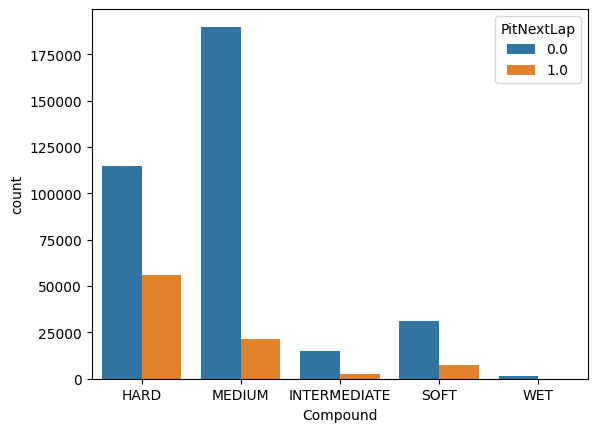

In [3]:
sb.countplot(data=df, x='Compound', hue='PitNextLap')

Counplot gives us a vague idea of data distribution but since i am trying to plot the relation between two categorical columns, I shall plot the distribution of proportions and normalize it in the same scale.

Text(0.5, 1.0, 'Intensity of realtionships')

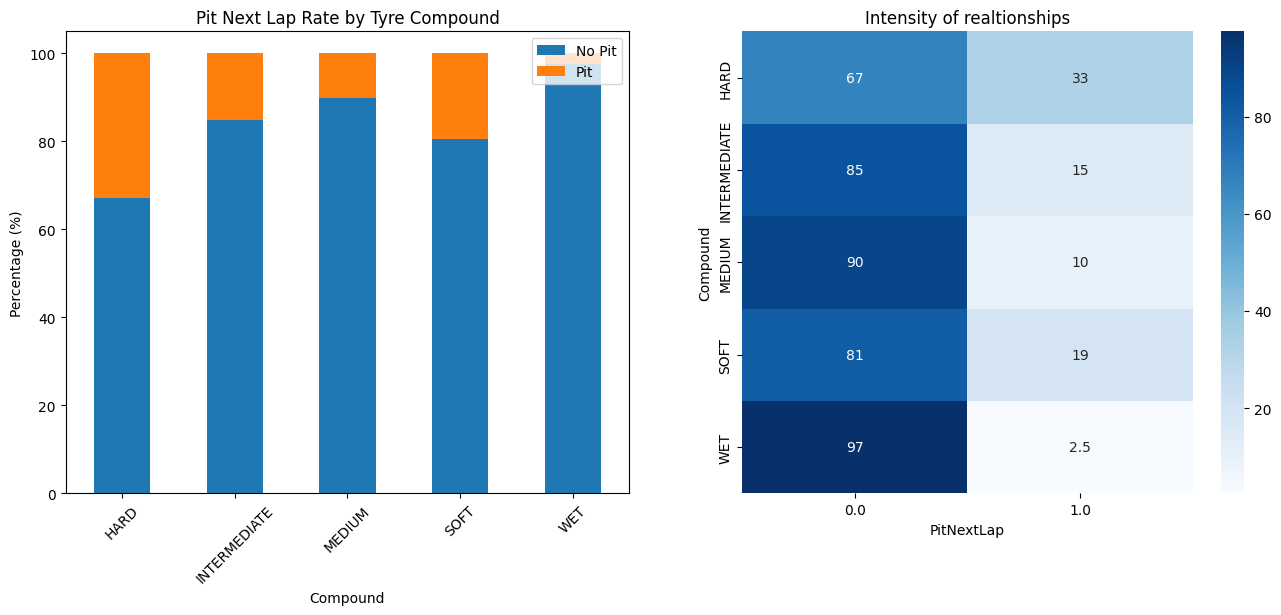

In [4]:
# Proportional grouped bar
fig, axes = plt.subplots(1,2, figsize=(16,6))

ct = pd.crosstab(df['Compound'], df['PitNextLap'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Pit Next Lap Rate by Tyre Compound')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['No Pit', 'Pit'], loc='upper right')

sb.heatmap(ct,annot=True,cmap='Blues',ax=axes[1])
axes[1].set_title("Intensity of realtionships")

Observations:
1. The HARD compound tires have more pit next lap rate as roughly 35% of F1 players running with HARD tire compounds performed a pit.
2. The players running with INTERMEDIATE & SOFT tire compounds have roughly same pit rate with SOFT tire compounds leading by just a small margin, indicating that SOFT tire compounds wear away slightly early than intermediate ones which is correct.
3. The MEDIUM compound tires performed well according to the expectations from it. It has lower pit rate than INTERMEDIATE & SOFT tires but higher than WET tires.
4. The WET tire compound has the lowest pit rate among all compounds, possibly due to wet track or weather conditions which allowed the driver to cover more laps before requiring any pit.

<Axes: xlabel='Year', ylabel='count'>

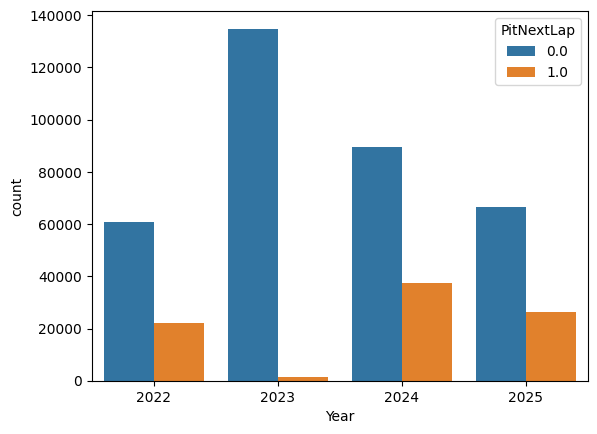

In [5]:
sb.countplot(data=df,x='Year',hue='PitNextLap')

Text(0.5, 0, 'Year')

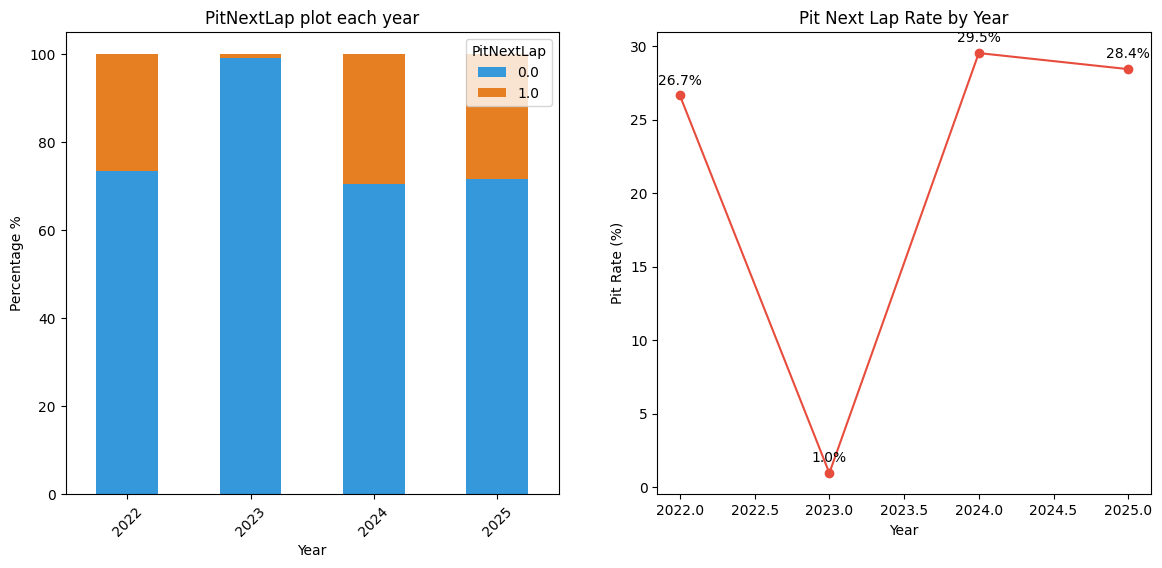

In [6]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

ct = pd.crosstab(df['Year'], df['PitNextLap'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#3498db', '#e67e22'], ax=axes[0])
axes[0].set_title("PitNextLap plot each year")
axes[0].set_ylabel("Percentage %")
axes[0].set_xlabel("Year")
axes[0].tick_params(axis='x',rotation=45)

pit_rate = df.groupby('Year')['PitNextLap'].mean() * 100

for x,y in (zip(pit_rate.index,pit_rate.values)):
    axes[1].annotate(f'{y:.1f}%', # print the value
                    (x,y), # where to print the value, provide the co-ordinates
                    textcoords='offset points', # as an offset measured in screen points from the marker.
                    xytext=(0,8),
                    ha='center')

pit_rate.plot(kind='line', marker='o', color='#e74c3c',ax=axes[1])
axes[1].set_ylabel('Pit Rate (%)')
axes[1].set_title('Pit Next Lap Rate by Year')
axes[1].set_xlabel("Year")

Observations:
1. The pit next lap rate has been almost consistent from the year 2022 to 2025 except just one year; 2023.
2. Year 2023 has the lowest pit rate among all 4 years of data, possibly due to policy changes in f1 race or due to drivers following a particular strategy of less pitting

In [7]:
df['Year'].value_counts()

Year
2023    136147
2024    127110
2025     92894
2022     82989
Name: count, dtype: int64

<Axes: xlabel='PitStop', ylabel='count'>

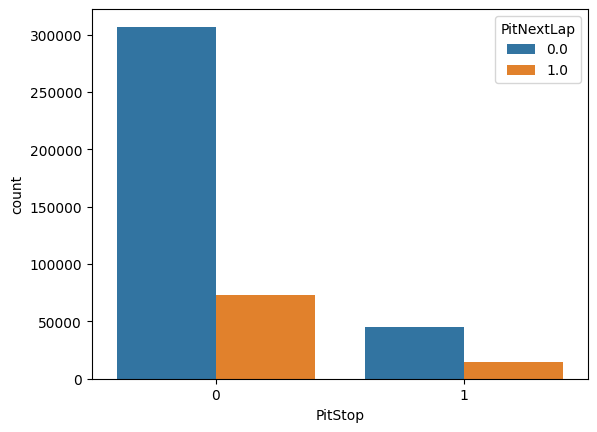

In [8]:
sb.countplot(data=df,x='PitStop',hue='PitNextLap')

[Text(0.5, 0, 'No PitNextLap'), Text(1.5, 0, 'PitNextLap')]

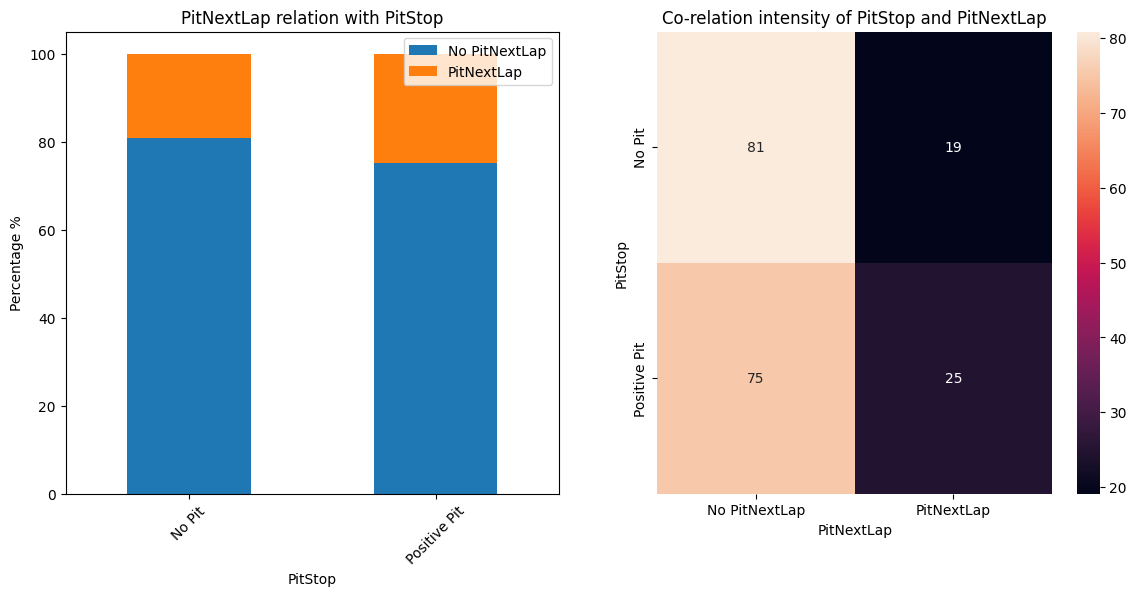

In [9]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

cross_tab = pd.crosstab(df['PitStop'],df['PitNextLap'],normalize='index') * 100
cross_tab.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title("PitNextLap relation with PitStop")
axes[0].set_ylabel("Percentage %")
axes[0].set_xticklabels(['No Pit','Positive Pit'])
axes[0].tick_params(axis='x',rotation=45)
axes[0].legend(['No PitNextLap', 'PitNextLap'], loc='upper right')

sb.heatmap(cross_tab,annot=True,ax=axes[1])
axes[1].set_title("Co-relation intensity of PitStop and PitNextLap")
axes[1].set_yticklabels(['No Pit','Positive Pit'])
axes[1].set_xticklabels(['No PitNextLap','PitNextLap'])


Observations:
1. It can be observed from both the graphs that, the chances of pitting reduces slightly when the driver doesn't perform a pit stop in the current lap.
2. Also the positive pitting in the current lap , only slightly increases the chances from 19% to 25% that the driver will perform the Pit in the next lap.

Therefore, there isn't a strong co-relation between the two attributes that can be a standalone factor in deriving out conclusions from it

In Formula 1, a STINT signifies the continuous period a car spends on track between leaving the pit lane (or starting the race) and its next pit stop. The stint number simply tracks how many of these intervals a driver has completed in a race.

Text(0.5, 1.0, 'Percentage of Stint with respect to PitNextLap')

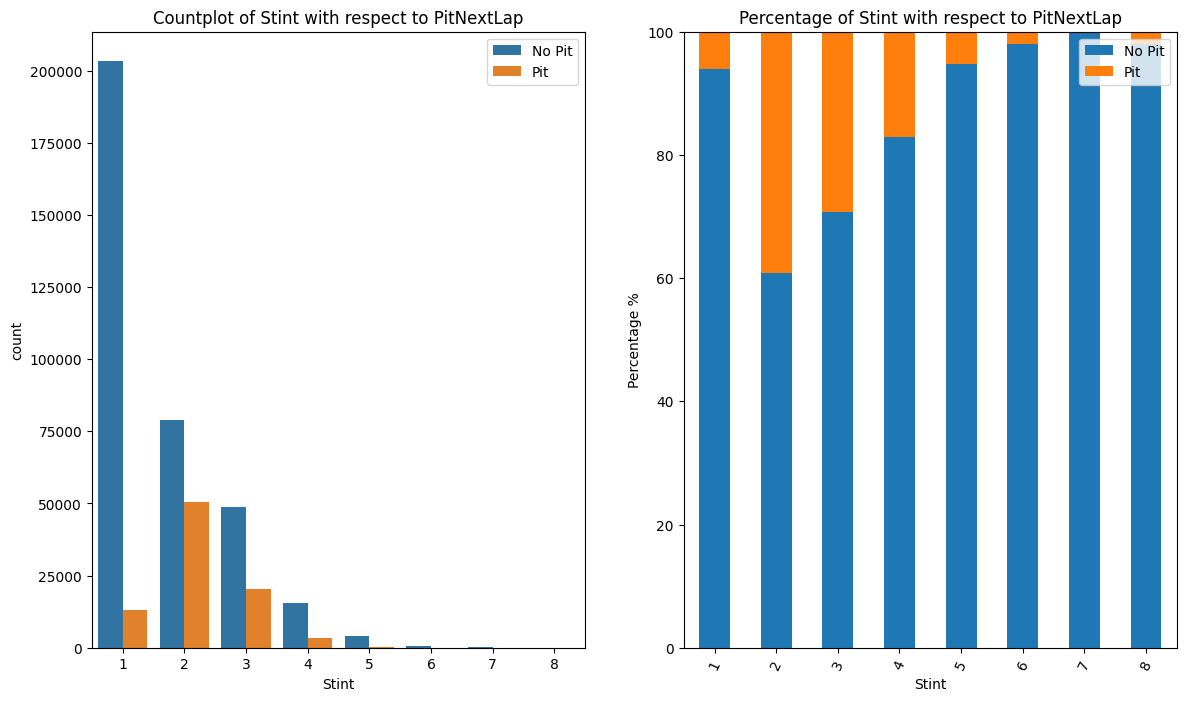

In [11]:
fig, axes = plt.subplots(1,2,figsize=(14,8))
fig
sb.countplot(data=df,x='Stint',hue='PitNextLap',ax=axes[0])
axes[0].set_title("Countplot of Stint with respect to PitNextLap")
axes[0].legend(['No Pit','Pit'])

ct= pd.crosstab(df['Stint'],df['PitNextLap'],normalize='index') * 100
#normalize the values means, dividing the class occurence by total number of total class

ct.plot(kind='bar',stacked=True,ax=axes[1])
axes[1].legend(['No Pit','Pit'],loc='upper right')
axes[1].set_ylabel("Percentage %")
axes[1].tick_params(axis='x',rotation=65)
axes[1].set_title("Percentage of Stint with respect to PitNextLap")

A stint is your current fuel and tyres. A new stint is started by a pitstop. 2 stints will mean 1 pitstop, 3 stints will require 2 pitstops and so on.

Observations:
1. It can be clearly observed from the graph that during the initial Stint (1) , only 20% of the drivers performed the Pit Stop i.e. just after one lap of the beginning of the race.
2. As the race proceeds, 60% of the drivers didn't pit while 40% of them pit in Stint (2)
3. At Stint (3), only 70% of the drivers didn't pit, while 30% of them pit.

Therefore, it can be clearly concluded that as the stint increases, the pit rate decreases with some exception in stint 8. Possibly there are some outliers, will check in different plot. 

In [13]:
df.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='str')

In [22]:
df['Position'].unique()

array([ 8,  4, 13,  7,  2,  5, 11,  1, 12, 10, 18, 15,  3, 20,  6, 17,  9,
       14, 16, 19])

Numerical feature vs categorical target

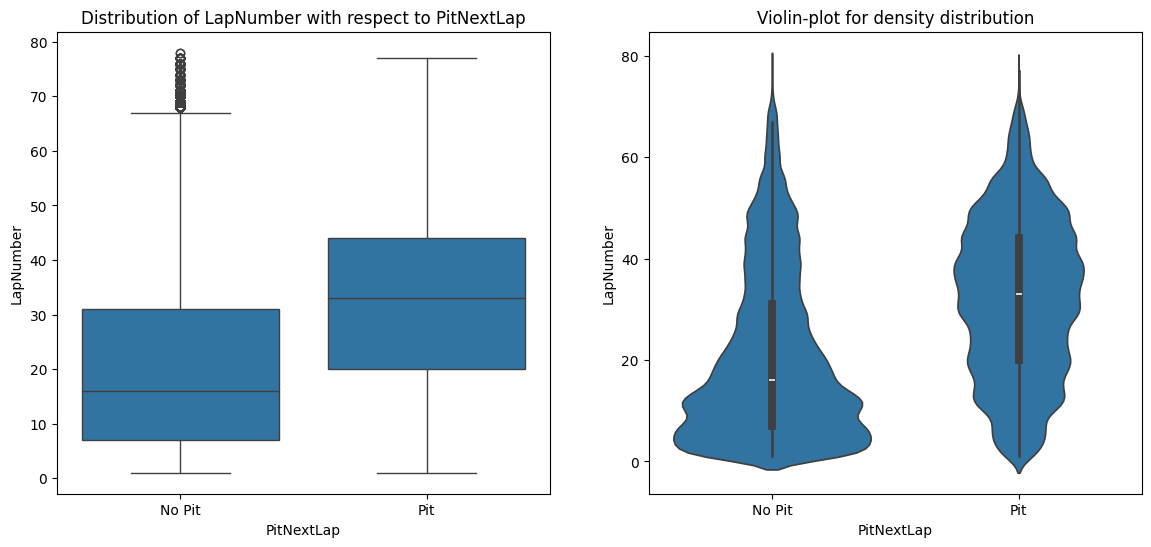

In [14]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='LapNumber',ax=axes[0])
axes[0].set_title("Distribution of LapNumber with respect to PitNextLap")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Pit","Pit"])

sb.violinplot(data=df,x="PitNextLap",y="LapNumber",ax=axes[1])
axes[1].set_title("Violin-plot for density distribution")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()


Observations 
1. Central Tendency & Spread

Pit laps have a higher median LapNumber (~33) vs No Pit (~17), suggesting pit stops are more likely to occur in the middle-to-later stages of a race
The IQR for Pit (~22–44) is wider and sits higher than No Pit (~10–30), indicating pit decisions are spread across a broader race window but skew later

2. Distribution Shape (Violin Plot)

No Pit has a massive dense bulge from laps 0–30, meaning the bulk of non-pit laps happen early in the race — drivers are simply not pitting in the opening phase
Pit violin is remarkably wide and evenly spread from ~15–60 laps, with multiple subtle bumps — this likely reflects multimodal pit strategy windows (lap 20–25 for early stoppers, lap 35–45 for medium strategy, later for one-stoppers)
The bumpy/irregular shape of the Pit violin is particularly interesting — it hints at distinct strategic clusters rather than one smooth pit window

3. Outliers

No Pit has notable outliers above lap 70 — these are probably the final laps where no one pits regardless of tyre state
Pit has very few outliers, and its whiskers extend to ~77, meaning some pit stops do happen very late (likely under safety car or strategic overcuts)

TyreLife – Number of laps on current tire

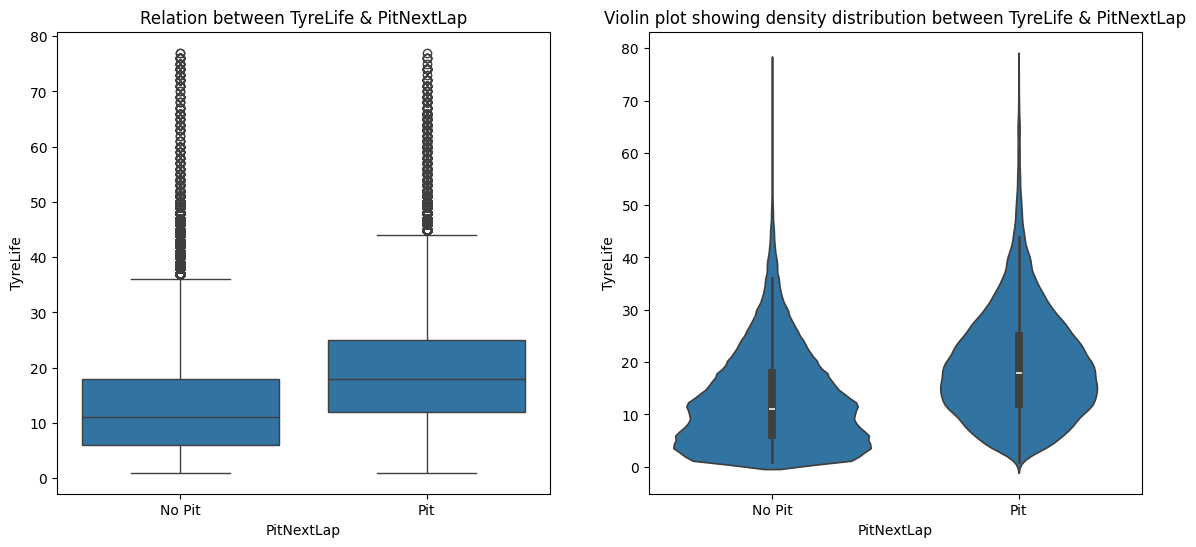

In [24]:
# again a numerical feature is plotted against categorical target
# therefore plotting the best plots for this strategy, boxplot and violinplot

fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='TyreLife',ax=axes[0])
axes[0].set_title("Relation between TyreLife & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='TyreLife',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between TyreLife & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

Obeservations: 

1. Central Tendency & Spread

Pit laps have a noticeably higher median TyreLife (~18 laps) compared to No Pit (~12 laps), which makes intuitive sense — drivers tend to pit after the tyre has been on longer
The IQR is wider for Pit (~15–25) vs No Pit (~8–17), meaning pit stop decisions happen across a broader range of tyre ages

2. Distribution Shape (Violin Plot)

No Pit shows a very fat bulge near 0–10 laps — most "no pit" observations cluster at low tyre ages, which is expected since fresh tyres rarely trigger a pit call
Pit has a more balanced, symmetrical belly centered around 15–25 laps, suggesting a fairly consistent tyre degradation window when pits are called
Both distributions have long upper tails, but No Pit's tail is heavier — some cars go extremely long stints without pitting (safety cars, strategy outliers)

3. Outliers

No Pit has substantially more outliers at high TyreLife values (dots above ~40), indicating edge cases where drivers run very old tyres but still don't pit that lap
Pit outliers exist too but are fewer and more bounded (~45–75 range)

Position – Driver’s position on that lap

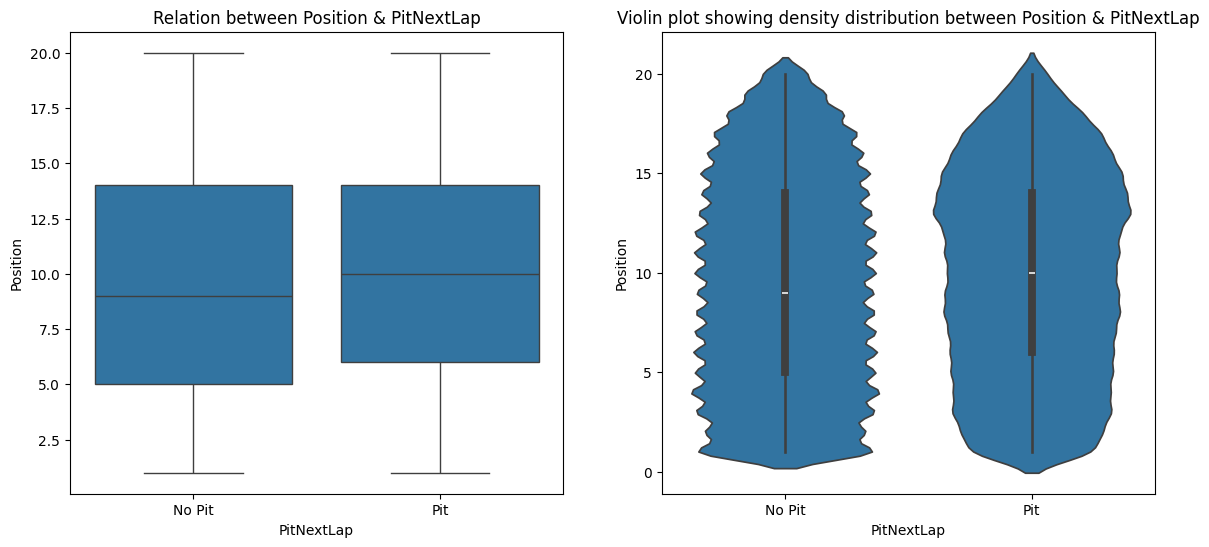

In [25]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='Position',ax=axes[0])
axes[0].set_title("Relation between Position & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='Position',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between Position & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

Observations 
1. Central Tendency & Spread

Medians are very close — No Pit ~9 vs Pit ~10 — an almost negligible difference
IQRs are nearly identical too (~5–14 for No Pit, ~6–14 for Pit), confirming that position alone barely distinguishes pit from non-pit laps
This is the weakest class separation seen so far compared to TyreLife and LapNumber

2. Distribution Shape (Violin Plot)

Both violins are broad and leaf-shaped, spanning nearly the full 1–20 position range — meaning pit stops happen at all grid positions with roughly equal probability
The jagged/serrated edges on the violin are a KDE artifact from the discrete nature of Position (it's an integer 1–20), not a real pattern — worth noting for presentation
No Pit has a slight bulge in the lower positions (1–8), suggesting front-runners are slightly less likely to pit on any given lap — possibly because they have more to lose from pitting
Pit is marginally fuller in the mid-to-back positions (10–16), hinting that midfield/backmarker teams may pit slightly more freely

3. Outliers

No extreme outliers in either class — Position is naturally bounded (1–20), so the distributions are clean with no tail concerns

In [26]:
df.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='str')

In [37]:
df['LapTime (s)'].median()

np.float64(90.521)

LapTime (s) – Lap time in seconds

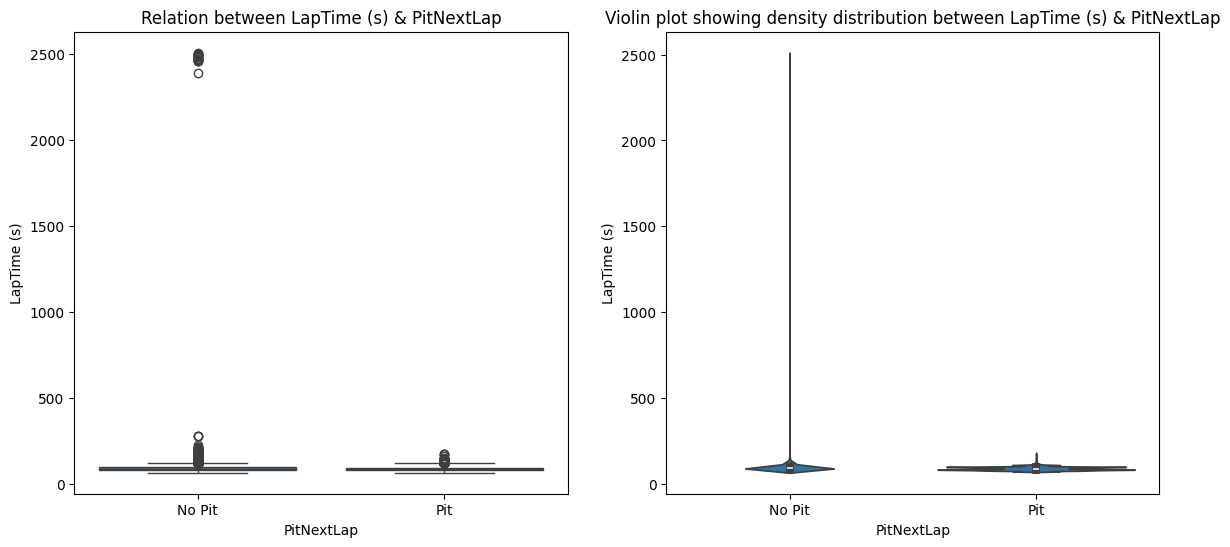

In [41]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='LapTime (s)',ax=axes[0])
axes[0].set_title("Relation between LapTime (s) & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='LapTime (s)',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between LapTime (s) & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

the plots are severely distorted by extreme outliers. 
The y-axis stretches to 2500s, compressing virtually all real data into a thin strip near the bottom. A lap time of 2500 seconds (~41 minutes) is physically impossible in F1 — these are almost certainly data quality issues: formation laps, red flag periods, or missing/corrupt entries.
Therefore i need to cap the y-axis (e.g., to ~200s) or remove outliers before visualizing. The current plots are not presentation-ready.

In [42]:
df_clean = df[df['LapTime (s)'] < 200]

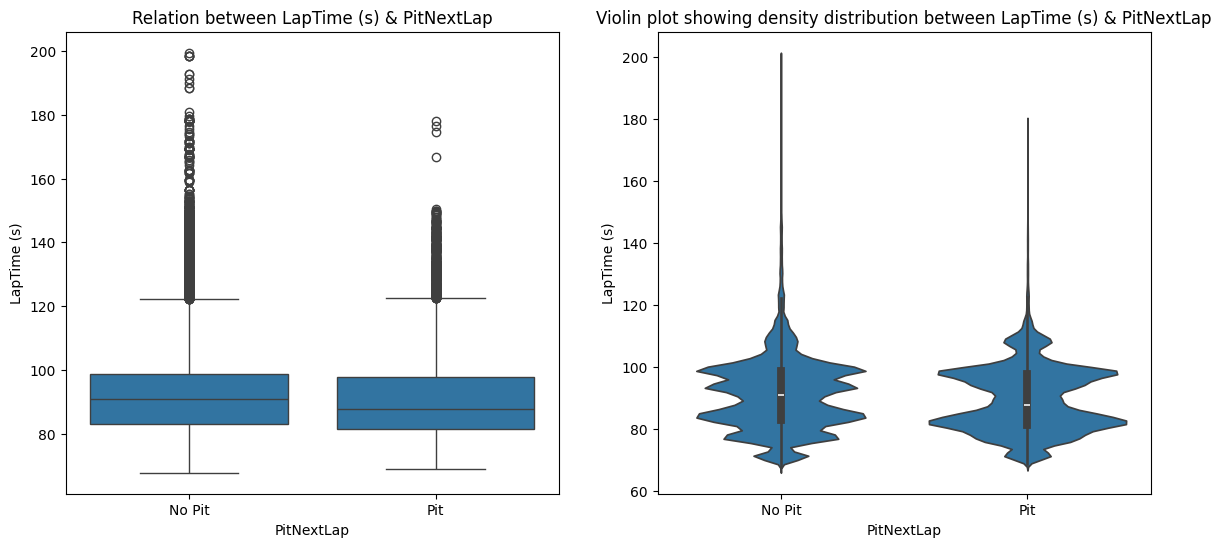

In [43]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df_clean,x='PitNextLap',y='LapTime (s)',ax=axes[0])
axes[0].set_title("Relation between LapTime (s) & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df_clean,x='PitNextLap',y='LapTime (s)',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between LapTime (s) & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

Observations
1. Central Tendency & Spread

No Pit median (~91s) is slightly higher than Pit (~88s) — a small but potentially meaningful difference
IQRs overlap heavily (~83–97 for No Pit, ~82–95 for Pit), so the separation is narrow
Interestingly, Pit laps tend to be marginally faster — counterintuitive at first glance, but explainable (see below)

2. Distribution Shape (Violin Plot)

Both violins share a jagged, multi-lobed shape — this reflects the discrete nature of different circuits, each with its own characteristic lap time range, creating natural clusters in the data
No Pit violin is noticeably wider and fuller, consistent with it being the majority class with more data density
Pit violin is narrower and more compact in its core band (~80–100s), suggesting pit laps cluster tighter around "normal" racing pace
Both show a sharp spike/bulge around 110–120s — likely a specific slow circuit or safety car laps within the 200s cutoff

3. The Counterintuitive Median Finding
The slight speed advantage on Pit laps likely reflects:

Drivers on fresher compounds pitting later tend to have better pace right before stopping
Strategic in-laps where drivers push hard to maximise track position before the pit window
Alternatively, No Pit laps include more degraded-tyre laps across a wider range of race phases, pulling the median up

4. Outliers

No Pit has significantly more outliers above ~130s — VSC laps, safety car bunching, or slow circuits still present even after the 200s cap
Pit outliers are fewer and cap around ~175s — in-laps can be slow if a driver is managing a damaged car or pitting under yellow flags

In [44]:
df.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='str')

LapTime_Delta – Change in lap time from previous lap

In [47]:
df['LapTime_Delta'].unique

<bound method Series.unique of 0         -7.564
1        -32.617
2         -7.540
3         -7.324
4          8.965
           ...  
439135    -0.076
439136    -0.083
439137    -0.182
439138    -0.001
439139    -0.123
Name: LapTime_Delta, Length: 439140, dtype: float64>

[Text(0, 0, 'No Pit'), Text(1, 0, 'Pit')]

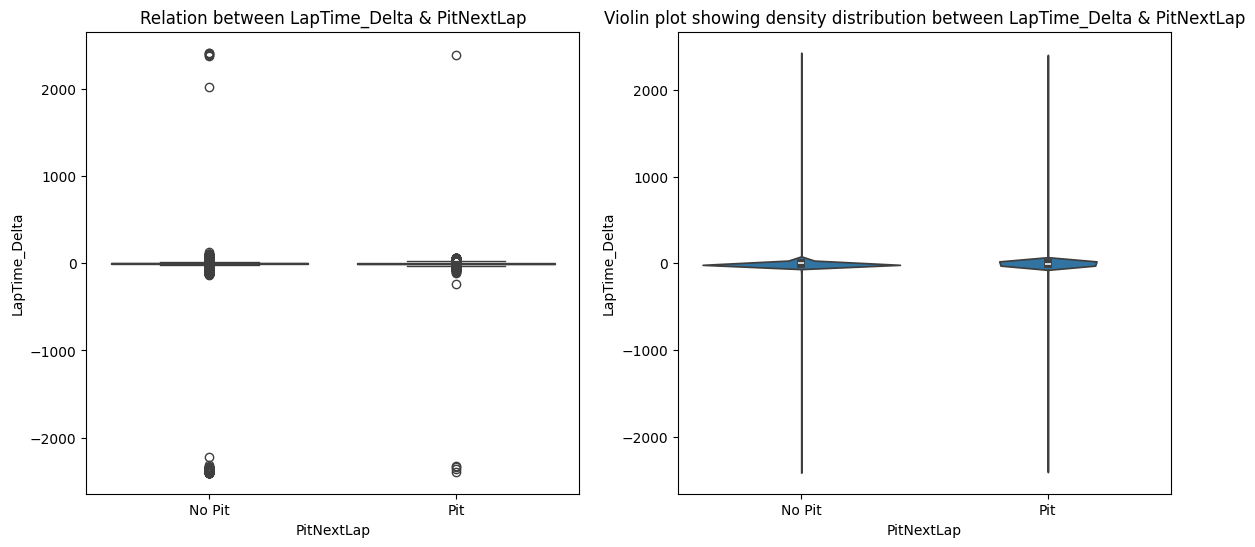

In [48]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df_clean,x='PitNextLap',y='LapTime_Delta',ax=axes[0])
axes[0].set_title("Relation between LapTime_Delta & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df_clean,x='PitNextLap',y='LapTime_Delta',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between LapTime_Delta & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])

Again the plots are distorted by extreme outliers on both sides positive and negative side of laptime delta. Some Y values are ranging upto ~ 2500 seconds which is not possible in F1 races unless there is an extreme accidental case but in that case too, the drivers are excluded from the race. Therefore, i need to scale down the Y axis to a nominal range where these plots can depict some meaningful patters.

In [51]:
df["LapTime_Delta"].mean()

np.float64(-3.770040479446941)

In [ ]:
df['LapTime_Delta'].value_counts().sort_values(ascending=False).head(20)

LapTime_Delta
 0.000    21473
-0.092     1183
-0.098     1042
-0.077      992
-0.074      876
-0.078      810
-0.095      796
-0.086      784
-0.066      734
-0.081      694
-0.038      656
-0.054      635
-0.083      628
-0.096      613
-0.051      601
-0.062      585
-0.072      574
-0.133      573
-0.080      570
-0.050      550
Name: count, dtype: int64

In [54]:
df['LapTime_Delta'].describe()


count    439140.000000
mean         -3.770040
std          43.945759
min       -2403.895000
25%          -8.884000
50%          -0.295000
75%           0.115000
max        2423.932000
Name: LapTime_Delta, dtype: float64